<style>
.lab8-hero {background:linear-gradient(130deg,#10263c,#176b79);color:white;
  border-radius:18px;padding:34px 40px;margin:8px 0 22px;font-family:Segoe UI,Arial,sans-serif}
.lab8-hero h1{font-size:2.1rem;margin:10px 0 8px;color:white}
.lab8-hero p{color:#dcecee;margin:0}.lab8-kicker{letter-spacing:.13em;font-size:.78rem;font-weight:700}
.lab8-note{background:#f1f6f7;border-left:4px solid #176b79;padding:12px 16px}
</style>
<div class="lab8-hero"><div class="lab8-kicker">UNIVERSIDAD DEL VALLE DE GUATEMALA · CC3084 · GRUPO 1 · SECCIÓN 10</div>
<h1>Laboratorio 8 · DuckDB</h1><p>Análisis incremental de Yellow y Green Taxi · NYC TLC · 2024–2026</p></div>

**Integrantes:** Jorge Gabriel Palacios Sales (231385), Pablo Daniel Barillas Moreno (22193) y Roberto Emiliano Otoniel (23968).

**Objetivo.** Consultar Parquet directamente, analizar viajes y calidad, incorporar años sin rehacer el flujo, comparar consultas con una tabla DuckDB y comunicar siete indicadores.

## 1 · Preparación y reproducibilidad

El repositorio se ejecuta con Docker Compose. Los datos originales viven en `data/raw/` y se excluyen de Git. Antes de esta libreta ejecute, desde el contenedor o siguiendo el README, `download_data.py --years 2024 2025 2026`, `verify_data.py --online`, `run_analysis.py`, `benchmark.py` y `build_dashboard.py`. Esta libreta comprueba que existen los resultados y los vuelve a generar si detecta una descarga posterior.

**Hipótesis exploratorias:** el volumen mensual y el perfil horario difieren entre tipos de taxi; los valores extremos pueden elevar la media de distancia; los tres años deben compararse con una ventana temporal común.

In [1]:
from pathlib import Path
import json, sys
import pandas as pd
from IPython.display import display, HTML, SVG

root = next(p for p in (Path.cwd(), *Path.cwd().parents)
            if (p / 'scripts' / 'lab8_common.py').exists())
sys.path.insert(0, str(root / 'scripts'))
from lab8_common import connect_with_view, parquet_files, sql_path_list
from run_analysis import run

files = parquet_files((2024, 2025, 2026))
assert files, 'Primero descargue los Parquet con scripts/download_data.py'
results = root / 'data' / 'processed' / 'results'
manifest_path = results / 'manifest.json'
if not manifest_path.exists() or json.loads(manifest_path.read_text())['archivos'] != len(files):
    run((2024, 2025, 2026))
manifest = json.loads(manifest_path.read_text())
conn = connect_with_view((2024, 2025, 2026))
display(HTML(f'<div class="lab8-note"><b>{len(files)} Parquet</b> · '
             f'DuckDB {manifest["duckdb"]} · '
             f'{len(manifest["resultados"])} consultas documentadas</div>'))

## 2 · Exploración directa de Parquet

`read_parquet` interpreta metadatos y columnas sin una importación previa. Los esquemas originales de Yellow y Green Taxi difieren; `union_by_name=true` permite leerlos juntos y la vista temporal `trips` unifica los nombres de fecha. Las muestras siguientes vienen directamente de los archivos originales.

In [2]:
for taxi in ('yellow', 'green'):
    path = next(p for p in files if p.parent.parent.name == taxi and p.parent.name == '2026')
    source = sql_path_list([path])
    print(f'\n{taxi.upper()} · {path.name} · esquema original')
    display(conn.execute(f'DESCRIBE SELECT * FROM read_parquet({source})').df().head(25))
    display(conn.execute(f'SELECT * FROM read_parquet({source}) LIMIT 3').df())


YELLOW · yellow_tripdata_2026-01.parquet · esquema original


,column_name,column_type,null,key,default,extra
0,VendorID,INTEGER,YES,None,None,None
1,tpep_pickup_datetime,TIMESTAMP,YES,None,None,None
2,tpep_dropoff_datetime,TIMESTAMP,YES,None,None,None
3,passenger_count,BIGINT,YES,None,None,None
4,trip_distance,DOUBLE,YES,None,None,None
5,RatecodeID,BIGINT,YES,None,None,None
6,store_and_fwd_flag,VARCHAR,YES,None,None,None
7,PULocationID,INTEGER,YES,None,None,None
8,DOLocationID,INTEGER,YES,None,None,None
9,payment_type,BIGINT,YES,None,None,None


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee
0,2,2026-01-01 00:54:04,2026-01-01 00:59:37,1,0.97,1,N,239,238,1,7.2,1.00,0.5,3.66,0.0,1.0,15.86,2.5,0.0,0.00
1,1,2026-01-01 00:34:04,2026-01-01 00:39:47,0,0.90,1,N,163,162,2,7.9,4.25,0.5,0.00,0.0,1.0,13.65,2.5,0.0,0.75
2,1,2026-01-01 00:57:06,2026-01-01 01:05:59,0,1.40,1,N,43,237,1,10.7,4.25,0.5,2.50,0.0,1.0,18.95,2.5,0.0,0.75



GREEN · green_tripdata_2026-01.parquet · esquema original


,column_name,column_type,null,key,default,extra
0,VendorID,INTEGER,YES,None,None,None
1,lpep_pickup_datetime,TIMESTAMP,YES,None,None,None
2,lpep_dropoff_datetime,TIMESTAMP,YES,None,None,None
3,store_and_fwd_flag,VARCHAR,YES,None,None,None
4,RatecodeID,BIGINT,YES,None,None,None
5,PULocationID,INTEGER,YES,None,None,None
6,DOLocationID,INTEGER,YES,None,None,None
7,passenger_count,BIGINT,YES,None,None,None
8,trip_distance,DOUBLE,YES,None,None,None
9,fare_amount,DOUBLE,YES,None,None,None


,VendorID,lpep_pickup_datetime,lpep_dropoff_datetime,store_and_fwd_flag,RatecodeID,PULocationID,DOLocationID,passenger_count,trip_distance,fare_amount,...,mta_tax,tip_amount,tolls_amount,ehail_fee,improvement_surcharge,total_amount,payment_type,trip_type,congestion_surcharge,cbd_congestion_fee
0,1,2026-01-01 00:27:58,2026-01-01 00:55:16,N,1,65,233,2,6.20,31.7,...,1.5,7.5,0.0,NaN,1.0,45.2,1,1,2.75,0.75
1,2,2026-01-01 00:44:33,2026-01-01 01:32:56,N,5,66,188,5,5.36,50.0,...,0.0,10.2,0.0,NaN,1.0,61.2,1,2,0.00,0.00
2,1,2026-01-01 00:23:45,2026-01-01 00:45:03,N,1,65,179,4,10.60,41.5,...,1.5,2.0,0.0,NaN,1.0,46.0,1,1,0.00,0.00


In [3]:
coverage = pd.read_csv(results / '01_cobertura.csv')
quality = pd.read_csv(results / '02_calidad.csv')
print('Archivos:', int(coverage.archivos.sum()),
      '| registros:', f'{int(coverage.viajes.sum()):,}')
display(coverage.groupby(['anio', 'tipo'], as_index=False)[['archivos', 'viajes']].sum())
display(quality)

Archivos: 64 | registros: 121,184,384


,anio,tipo,archivos,viajes
0,2024,green,12,660218
1,2024,yellow,12,41169720
2,2025,green,12,591375
3,2025,yellow,12,48722602
4,2026,green,8,337114
5,2026,yellow,8,29703355


,anio,tipo,viajes,sin_recogida,fuera_de_anio,duracion_negativa,distancia_nula,distancia_negativa,distancia_cero,importe_negativo,importe_nulo,pasajeros_nulos
0,2024,green,660218,0,20,2,0,0,34574,2174,0,24328
1,2024,yellow,41169720,0,56,1575,0,0,776305,609344,0,4091232
2,2025,green,591375,0,21,1344,0,0,24438,1774,0,49880
3,2025,yellow,48722602,0,29,2235,0,0,1402958,973721,0,11611894
4,2026,green,337114,0,14,5,0,0,12212,1023,0,48775
5,2026,yellow,29703355,0,17,10,0,0,952231,161835,0,7716688


**Decisión de calidad.** Conservamos los registros originales. Las métricas de viajes excluyen recogidas fuera del año del archivo. Para distancias típicas usamos mediana de valores positivos; para propinas usamos solo pagos con tarjeta y tarifas positivas. `payment_type=0` y pasajeros nulos se informan como problemas de interpretación. La tabla completa de consultas, objetivos, resultados y decisiones está en `docs/consultas.md`.

## 3 · Preguntas analíticas y resultados

Las doce preguntas están implementadas en `sql/01_*.sql` a `sql/12_*.sql`: cobertura, calidad, serie mensual, distancias, pagos, horas, propinas, días, zonas, duración, importes y comparación enero–agosto. La vista lee los archivos requeridos según el año y el tipo. Aquí se muestran resultados resumidos; cada CSV completo es regenerable con `scripts/run_analysis.py`.

In [4]:
comparable = pd.read_csv(results / '12_comparacion_ene_ago.csv')
distances = pd.read_csv(results / '04_distancias.csv')
payments = pd.read_csv(results / '05_pagos.csv')
display(comparable)
display(distances[['anio','tipo','media_millas','p50_millas','p99_millas','mas_100_millas']])

,anio,tipo,viajes,importe_medio_usd,distancia_p50_millas,tarjeta_pct,propina_sobre_tarifa_pct
0,2024,green,443409,24.04,1.96,67.93,19.47
1,2024,yellow,26388138,28.37,1.80,74.05,21.99
2,2025,green,397912,24.97,2.02,69.42,19.59
3,2025,yellow,31556412,27.49,1.89,63.81,22.19
4,2026,green,337100,25.61,2.14,65.25,20.93
5,2026,yellow,29703338,30.40,1.92,63.77,21.53


,anio,tipo,media_millas,p50_millas,p99_millas,mas_100_millas
0,2024,green,17.96,1.97,16.64,235
1,2024,yellow,5.07,1.79,20.13,1613
2,2025,green,19.84,2.06,17.75,209
3,2025,yellow,7.05,1.91,19.63,2870
4,2026,green,13.85,2.14,17.92,72
5,2026,yellow,5.74,1.93,19.60,1223


## 4 · Siete indicadores visualizados

Cada figura se obtiene de consultas DuckDB documentadas. Para comparar 2024, 2025 y 2026 se emplea enero–agosto en los indicadores anuales; 2026 todavía no tiene doce meses publicados. El tablero conjunto también está en `docs/tablero.html` y Metabase se reproduce con `scripts/create_metabase_dashboard.py`.

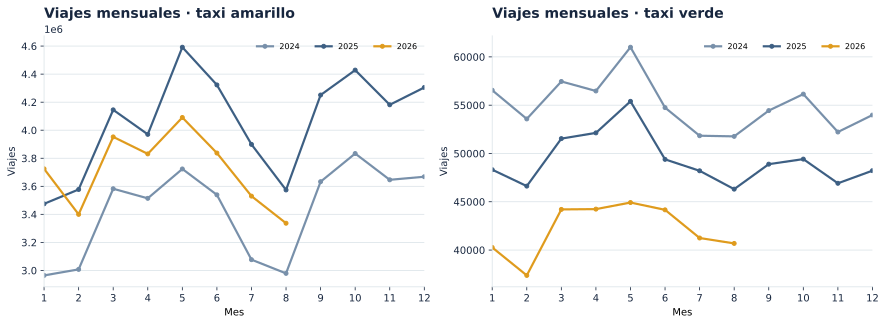

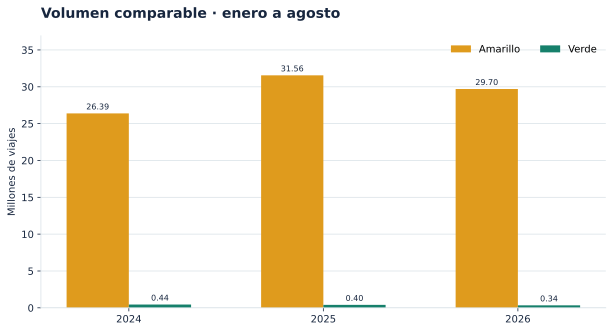

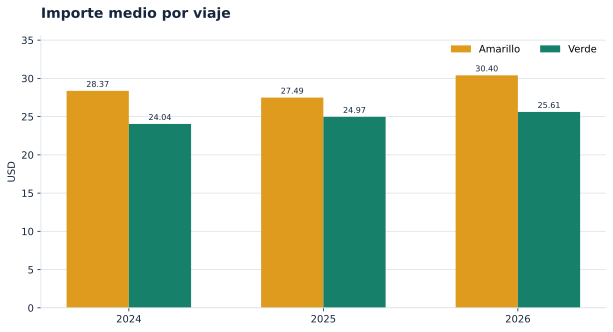

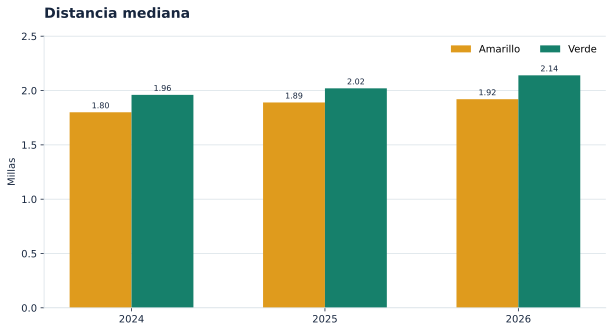

In [5]:
figures = root / 'docs' / 'figures'
for name in ('01_viajes_mensuales.svg', '02_volumen_comparable.svg',
             '03_importe_medio.svg', '04_distancia_mediana.svg'):
    display(SVG(filename=str(figures / name)))

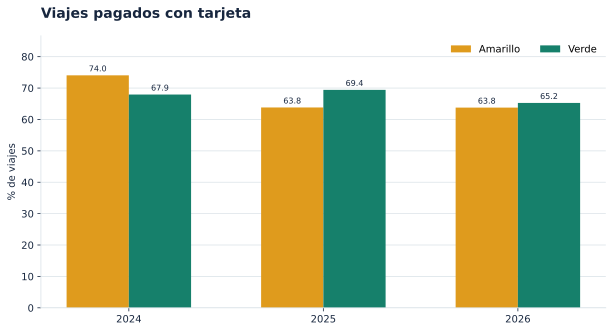

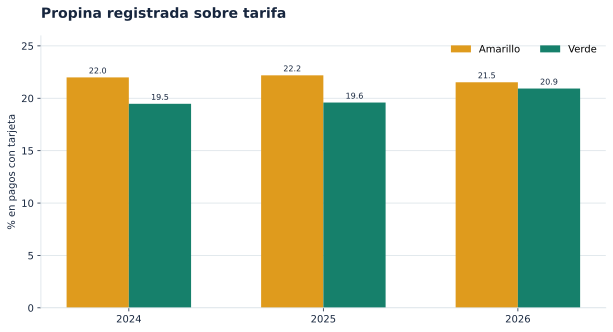

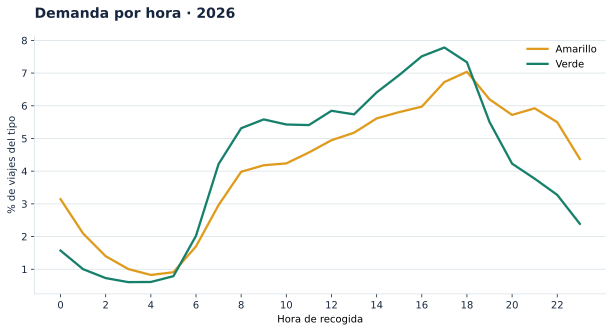

In [6]:
for name in ('05_tarjeta.svg', '06_propinas.svg', '07_horas_2026.svg'):
    display(SVG(filename=str(figures / name)))

**Interpretación.** En enero–agosto, Yellow Taxi pasa de 26.39 M viajes (2024) a 29.70 M (2026), mientras Green Taxi desciende de 443 mil a 337 mil. La distancia mediana es cercana a dos millas para ambos tipos; las medias se elevan por extremos. La cuota registrada como tarjeta en amarillo baja de 74.05% a 63.77%, pero aumenta el código 0, por lo que no atribuimos el cambio a preferencias de pago sin investigar la codificación.

## 5 · Benchmark: Parquet frente a tabla DuckDB

`scripts/benchmark.py` materializa una proyección de seis columnas, ejecuta las **mismas tres consultas** sobre ambos orígenes, verifica equivalencia de resultados y cronometra tres repeticiones. Los tamaños son 16 archivos (2026), 40 (2024+2026) y 64 (los tres años). La tabla de abajo usa la mediana de tiempos; la creación de la tabla es un costo previo distinto del tiempo de consulta.

In [7]:
benchmark_path = root / 'docs' / 'benchmark_resultados.csv'
assert benchmark_path.exists(), 'Ejecute primero scripts/benchmark.py'
benchmark = pd.read_csv(benchmark_path)
view = benchmark.pivot_table(index=['escenario','consulta'], columns='fuente',
                             values='mediana_segundos').reset_index()
view['Parquet / DuckDB'] = (view['Parquet'] / view['DuckDB']).round(2)
display(view)

fuente,escenario,consulta,DuckDB,Parquet,Parquet / DuckDB
0,2024+2025+2026,conteo_tipo,1.2698,1.4631,1.15
1,2024+2025+2026,importe_mensual,3.4906,9.8322,2.82
2,2024+2025+2026,pagos,2.7341,7.7503,2.83
3,2024+2026,conteo_tipo,0.8012,0.4698,0.59
4,2024+2026,importe_mensual,1.5462,3.7812,2.45
5,2024+2026,pagos,2.0167,6.3052,3.13
6,2026,conteo_tipo,0.1630,0.1712,1.05
7,2026,importe_mensual,0.5866,1.7957,3.06
8,2026,pagos,0.4618,1.5366,3.33


**Lectura del benchmark.** La tabla materializada suele acelerar agregaciones repetidas sobre el conjunto grande, pero exige espacio y tiempo de construcción. Parquet permite consultas ad hoc y nuevos meses sin cargar una tabla; en consultas simples o algunos tamaños puede igualar o superar a la tabla. Las mediciones dependen de caché, hardware y orden de ejecución. `docs/benchmark_detalle.csv` conserva cada repetición.

## 6 · Discusión y conclusiones

1. **Utilidad de DuckDB.** SQL directo sobre Parquet, proyección de columnas, lectura de metadatos, `union_by_name` y almacenamiento local facilitaron un flujo sin servidor SQL tradicional.
2. **Parquet directo.** Ahorra la importación y acepta archivos mensuales nuevos; consultas repetidas pueden pagar de nuevo el costo de lectura y hay que manejar esquemas distintos.
3. **Tabla materializada.** Mejora varias agregaciones repetidas, pero duplica una parte de los datos, requiere reconstrucción al entrar nuevos archivos y puede bloquearse si otro proceso abre la base para escritura.
4. **Frente a Pandas.** DuckDB agrega millones de filas sin cargar todo el conjunto como un DataFrame en memoria; Pandas queda para los resultados pequeños y las figuras.
5. **Incrementalidad.** La descarga evita duplicados y usa rutas `tipo/año/mes`; la vista deriva año y tipo del nombre, mientras `union_by_name` tolera columnas añadidas o ausentes.
6. **Automatización futura.** Programar descarga, inventario, pruebas de integridad, actualización de indicadores y alertas de cambios de esquema.
7. **Reproducibilidad.** Dependencias fijadas en Docker, SQL versionado, filtros explícitos y datos excluidos de Git permiten rehacer los resultados.
8. **Aprendizaje a escala.** Nulos, códigos de pago nuevos y valores extremos cambian de manera material la interpretación; una muestra pequeña podría no revelarlo.

**Limitaciones:** 2026 solo incluye enero–agosto; importes nominales sin ajuste de inflación; los cambios observados no prueban causalidad. Véanse `docs/consultas.md` y `docs/metodologia.md` para detalle.

In [8]:
conn.close()
print('Laboratorio ejecutado con resultados visibles y fuentes trazables.')

Laboratorio ejecutado con resultados visibles y fuentes trazables.
